Enter a non-negative integer:  0


Total blocks created: 40
Block 1: Start time = 0.0, End time = 193.50233891401624, Duration = 193.50233891401624 seconds, Length = 237
Block 2: Start time = 194.32226407890613, End time = 393.5640791471517, Duration = 199.24181506824556 seconds, Length = 244
Block 3: Start time = 394.38400431204155, End time = 553.449486300682, Duration = 159.06548198864044 seconds, Length = 195
Block 4: Start time = 554.2694114655719, End time = 1629.19130263623, Duration = 1074.921891170658 seconds, Length = 1312
Block 5: Start time = 1630.0112278011197, End time = 1638.2104794500187, Duration = 8.199251648899008 seconds, Length = 11
Block 6: Start time = 1639.0304046149088, End time = 1774.3180568217422, Duration = 135.2876522068334 seconds, Length = 166
Block 7: Start time = 1775.137981986632, End time = 1782.5173084706412, Duration = 7.379326484009198 seconds, Length = 10
Block 8: Start time = 1783.337233635531, End time = 2082.6099188203443, Duration = 299.2726851848133 seconds, Length = 366
Bloc

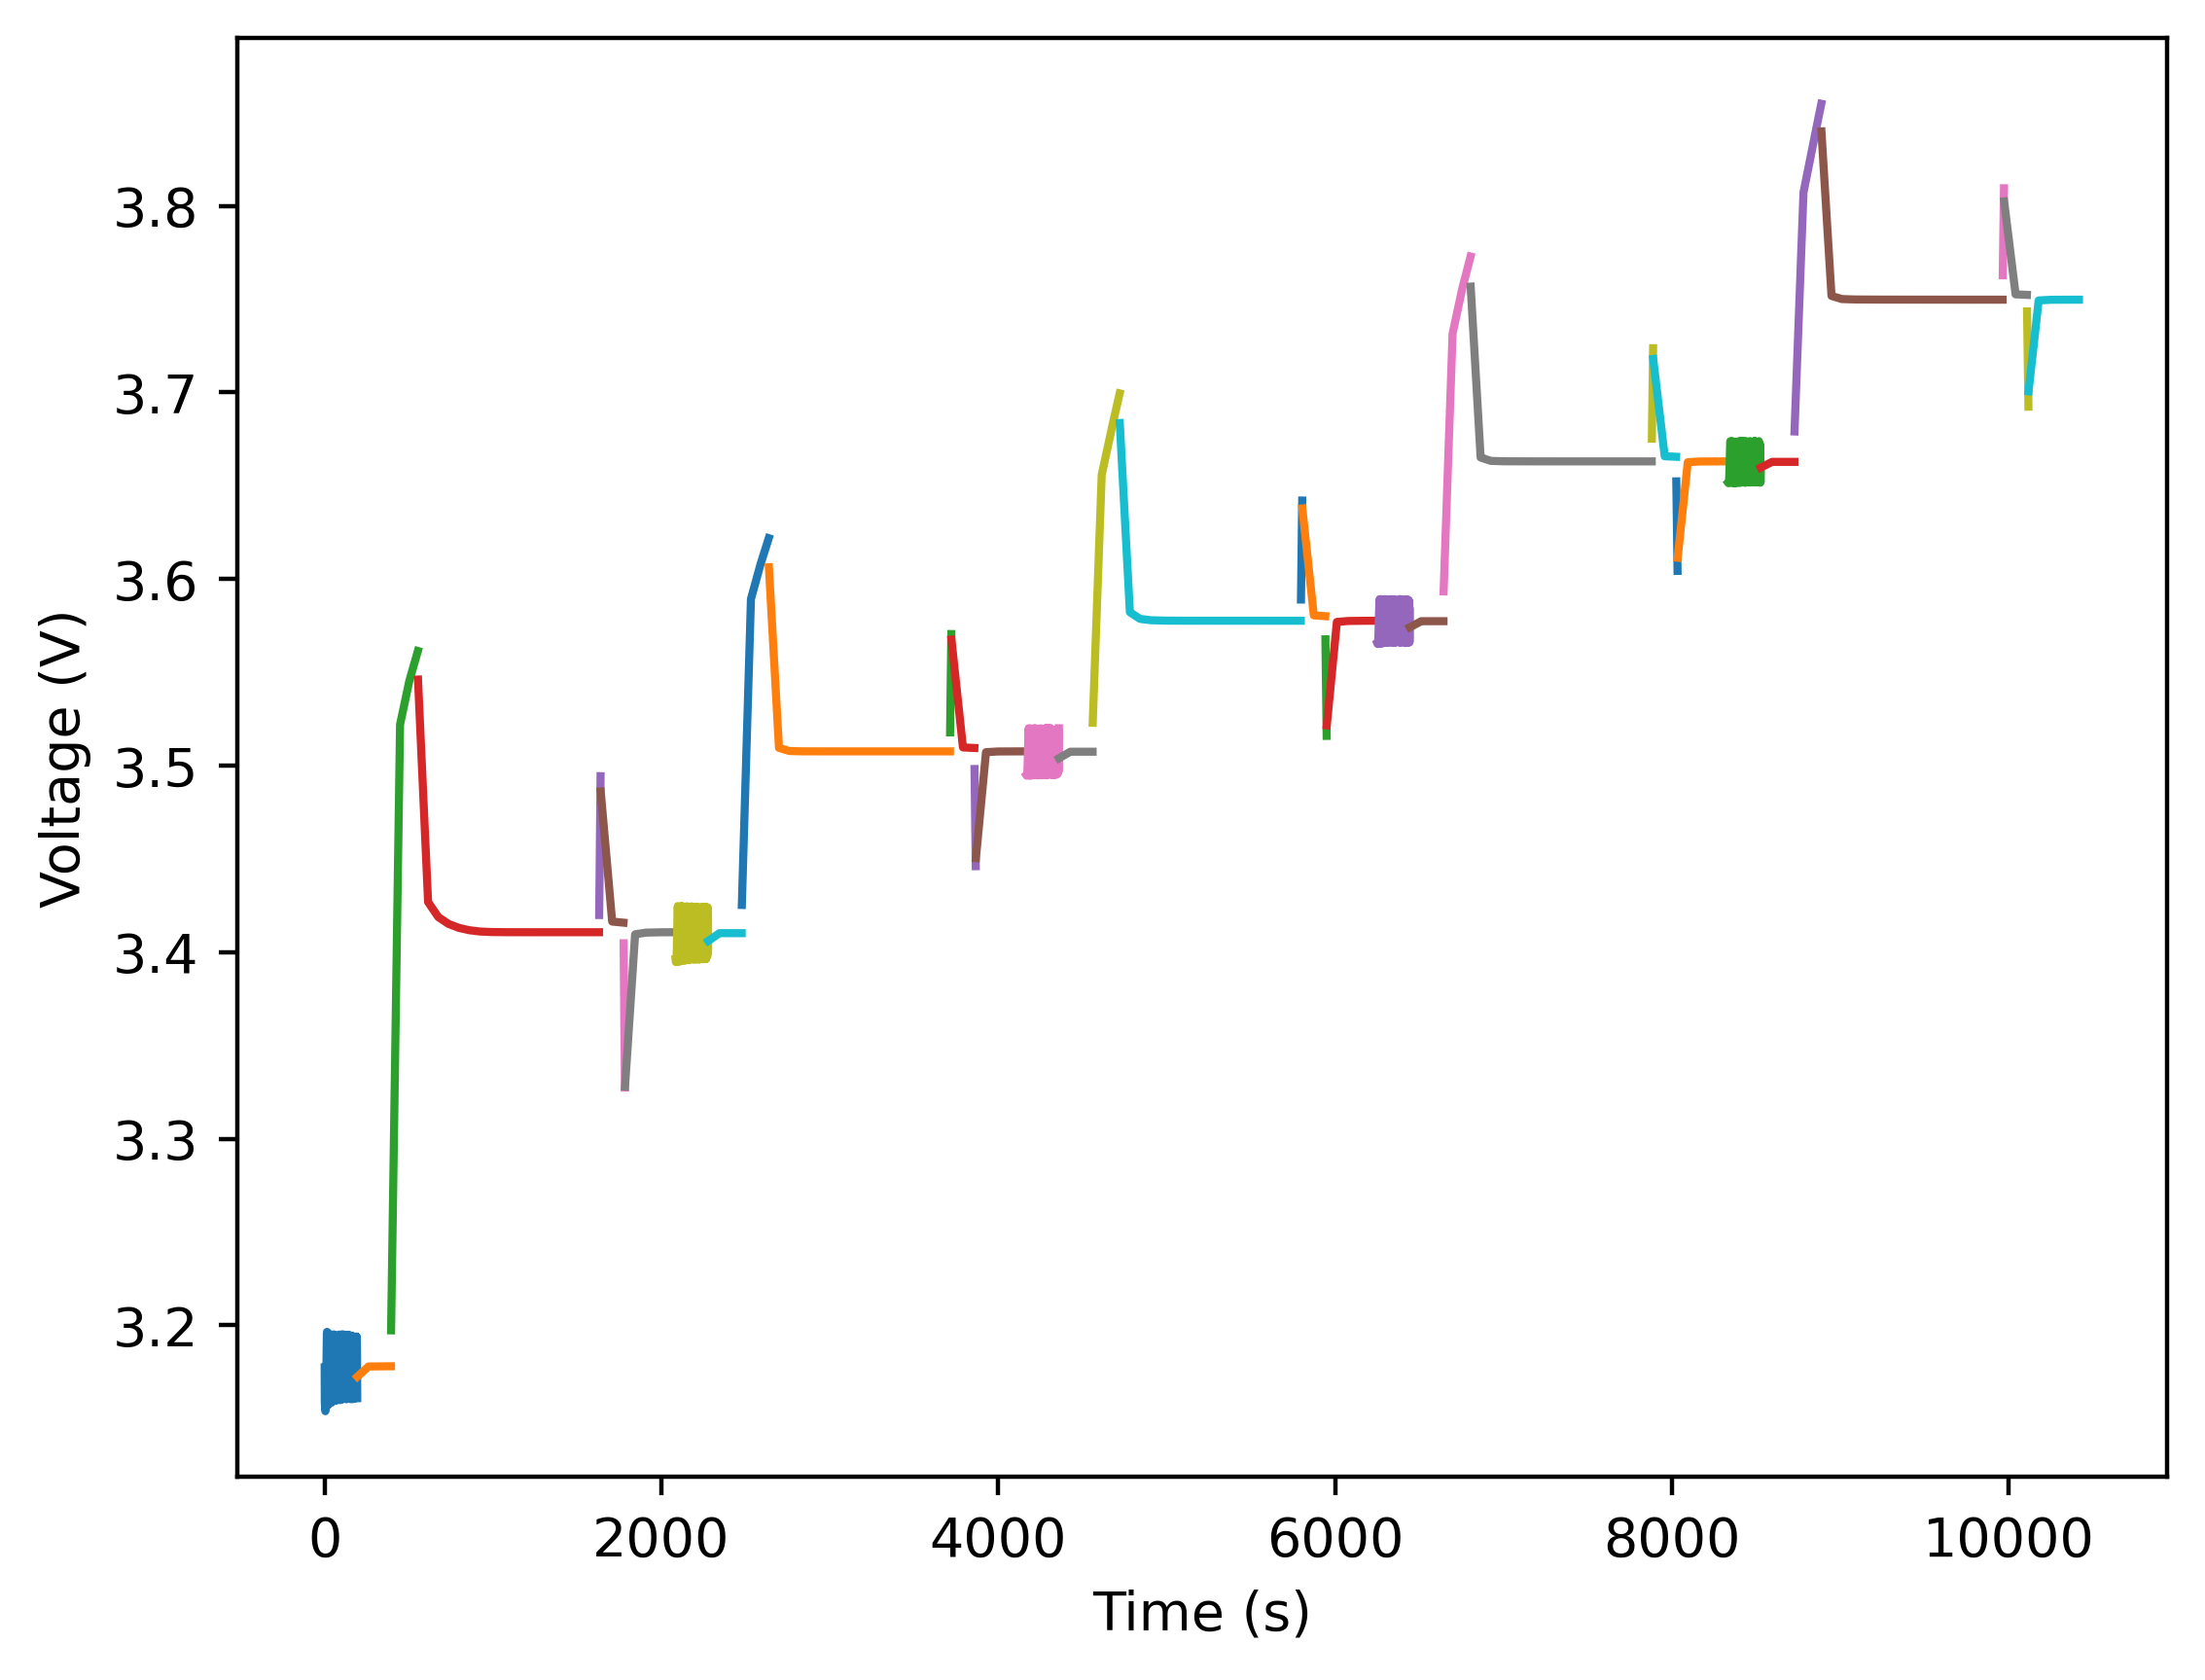

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy.interpolate import interp1d
from scipy.signal import find_peaks, welch
import os
from scipy.optimize import curve_fit

plt.rcParams['figure.dpi'] = 400

def load_files(integer):
    folder_path = "simulation_results_low_soc"
    file_extension = f"_{integer}.npy"

    for filename in os.listdir(folder_path):
        if filename.endswith(file_extension):
            if filename.startswith("params"):
                theta = np.load(os.path.join(folder_path, filename))
            elif filename.startswith("time_data"):
                t = np.load(os.path.join(folder_path, filename))
            elif filename.startswith("voltage_data"):
                v = np.load(os.path.join(folder_path, filename))
            elif filename.startswith("current_data"):
                current = np.load(os.path.join(folder_path, filename))

    return theta, t, v, current

# Prompt user for a non-negative integer
#integer = int(input("Enter a non-negative integer: "))
integer = 0
# Load files based on the provided integer
theta, t, v, current = load_files(integer)
p1, p2, p3, p4, p5, p6, p7, p8 = theta[9:17]

# Interpolate the entire dataset
#num_points = 5000  # Number of points for interpolation
t_interp = np.linspace(t[0], t[-1], len(t))
v_interp_func = interp1d(t, v, kind='linear')
i_interp_func = interp1d(t, current, kind='linear')

v_interp = v_interp_func(t_interp)
i_interp = i_interp_func(t_interp)

# Break the interpolated data into blocks
block_durations = [p8, 200, p2, p3, p5, p6, p5, 300]
full_durations = block_durations * 5  # Adjust the repetition count as needed

start_times = [0]
for duration in full_durations[:-1]:  # Exclude the last duration to avoid going out of bounds
    next_start_time = start_times[-1] + duration
    start_times.append(next_start_time)
end_times = [start + duration for start, duration in zip(start_times, full_durations)]

def find_index(time_array, time):
    return np.searchsorted(time_array, time, side='right')

start_indices = [find_index(t_interp, time) for time in start_times]
end_indices = [find_index(t_interp, time) - 1 for time in end_times]  # -1 because end index is inclusive

start_indices[0] = 0

tBlocks = [t_interp[start:end+1] for start, end in zip(start_indices, end_indices)]  # +1 because end index is inclusive
vBlocks = [v_interp[start:end+1] for start, end in zip(start_indices, end_indices)]
iBlocks = [i_interp[start:end+1] for start, end in zip(start_indices, end_indices)]

# Print the blocks
print(f"Total blocks created: {len(tBlocks)}")
for i, block in enumerate(tBlocks):
    if len(block) > 0:
        print(f"Block {i+1}: Start time = {block[0]}, End time = {block[-1]}, Duration = {block[-1] - block[0]} seconds, Length = {len(block)}")
    else:
        print(f"Block {i+1} is empty!")

# Plot original and interpolated blocks
plt.figure()

# Plot original blocks
for i, (t_block, v_block, i_block) in enumerate(zip(tBlocks, vBlocks, iBlocks)):
    if len(t_block) > 0:
        plt.plot(t_block, v_block, label=f'Voltage Block {i+1}')

plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
#plt.legend()
plt.show()

interp_tBlocks = tBlocks
interp_vBlocks = vBlocks
interp_iBlocks = iBlocks

In [2]:
# #interpolate the divided blocks
# # Interpolate each block
# interp_tBlocks, interp_vBlocks, interp_iBlocks = [], [], []
# #num_points = 500  # Number of points for interpolation

# for t_block, v_block, i_block in zip(tBlocks, vBlocks, iBlocks):
#     if len(t_block) > 1:
#         # Define interpolation functions
#         t_interp_func = np.linspace(t_block[0], t_block[-1], len(t_block))
#         v_interp_func = interp1d(t_block, v_block, kind='linear')
#         i_interp_func = interp1d(t_block, i_block, kind='linear')

#         # Apply interpolation
#         interp_tBlocks.append(t_interp_func)
#         interp_vBlocks.append(v_interp_func(t_interp_func))
#         interp_iBlocks.append(i_interp_func(t_interp_func))
#     else:
#         # If the block has only one or no points, append the original data
#         interp_tBlocks.append(t_block)
#         interp_vBlocks.append(v_block)
#         interp_iBlocks.append(i_block)

# # Plot original and interpolated blocks
# plt.figure()

# # # Plot original blocks
# for i, (t_block, v_block, i_block) in enumerate(zip(tBlocks, vBlocks, iBlocks)):
#     if len(t_block) > 0:
#         plt.plot(t_block, v_block, label=f'Original Voltage Block {i+1}')
#         #plt.plot(t_block, i_block, 'x', label=f'Original Current Block {i+1}')

# # Plot interpolated blocks
# for i, (t_block, v_block, i_block) in enumerate(zip(interp_tBlocks, interp_vBlocks, interp_iBlocks)):
#     plt.plot(t_block, v_block, 'x',label=f'Interpolated Voltage Block {i+1}')
#     #plt.plot(t_block, i_block, label=f'Interpolated Current Block {i+1}', linestyle='--')

# plt.xlabel('Time (s)')
# plt.ylabel('Voltage (V)')
# #plt.legend()
# plt.show()

In [5]:

def summarize_peak_time_differences(time_uniform, output_voltage_uniform):
    positive_peaks, _ = find_peaks(output_voltage_uniform)
    negative_peaks, _ = find_peaks(-output_voltage_uniform)
    all_peaks = np.sort(np.concatenate((positive_peaks, negative_peaks)))
    time_differences = []
    paired_peaks = []

    for i in range(len(all_peaks) - 1):
        if (all_peaks[i] in positive_peaks and all_peaks[i+1] in negative_peaks) or \
           (all_peaks[i] in negative_peaks and all_peaks[i+1] in positive_peaks):
            time_diff = time_uniform[all_peaks[i+1]] - time_uniform[all_peaks[i]]
            time_differences.append(time_diff)
            paired_peaks.append((all_peaks[i], all_peaks[i+1]))

    max_time_diff = np.max(time_differences) if time_differences else np.nan
    min_time_diff = np.min(time_differences) if time_differences else np.nan
    mean_time_diff = np.mean(time_differences) if time_differences else np.nan
    std_time_diff = np.std(time_differences) if time_differences else np.nan

    return max_time_diff, min_time_diff, mean_time_diff, std_time_diff

def summarize_impedance_phase(frequency_ranges, impedance, phase_shift, frequencies):
    def average_and_std_over_frequency_range(frequencies, data, frequency_ranges):
        averages = []
        stds = []
        for f_min, f_max in frequency_ranges:
            mask = (frequencies >= f_min) & (frequencies < f_max)
            avg = np.mean(data[mask])
            std = np.std(data[mask])
            averages.append(avg)
            stds.append(std)
        return averages, stds

    average_impedance, std_impedance = average_and_std_over_frequency_range(frequencies, impedance, frequency_ranges)
    average_phase, std_phase = average_and_std_over_frequency_range(frequencies, phase_shift, frequency_ranges)

    return average_impedance, std_impedance, average_phase, std_phase

def calculate_power_and_bandwidth(output_voltage_uniform, time_uniform, percentage=0.95):
    sampling_rate = 1 / (time_uniform[1] - time_uniform[0])
    frequencies, psd = welch(output_voltage_uniform, fs=sampling_rate)
    total_power = np.trapz(psd, frequencies)

    def power_bandwidth(frequencies, psd, percentage=0.95):
        cumulative_power = np.cumsum(psd) / np.sum(psd)
        lower_index = np.where(cumulative_power >= (1 - percentage) / 2)[0][0]
        upper_index = np.where(cumulative_power <= 1 - (1 - percentage) / 2)[0][-1]
        bandwidth = frequencies[upper_index] - frequencies[lower_index]
        return frequencies[lower_index], frequencies[upper_index], bandwidth

    lower_freq, upper_freq, bandwidth = power_bandwidth(frequencies, psd, percentage=percentage)

    return total_power, lower_freq, upper_freq, bandwidth

def calculate_impedance_and_phase(time, input_current, output_voltage):
    n = len(time)
    d = time[1] - time[0]
    input_fft = fft(input_current)
    voltage_fft = fft(output_voltage)
    frequencies = fftfreq(n, d)
    impedance = np.abs(voltage_fft / input_fft)
    phase_shift = np.angle(voltage_fft) - np.angle(input_fft)
    return frequencies, impedance, phase_shift

def combined_summary_chirp(time_uniform, input_current_uniform, output_voltage_uniform, frequency_ranges, percentage=0.95):
    max_time_diff, min_time_diff, mean_time_diff, std_time_diff = summarize_peak_time_differences(time_uniform, output_voltage_uniform)
    frequencies, impedance, phase_shift = calculate_impedance_and_phase(time_uniform, input_current_uniform, output_voltage_uniform)
    average_impedance, std_impedance, average_phase, std_phase = summarize_impedance_phase(frequency_ranges, impedance, phase_shift, frequencies)
    total_power, lower_freq, upper_freq, bandwidth = calculate_power_and_bandwidth(output_voltage_uniform, time_uniform, percentage)

    results = {
        "peak_time_differences": {
            "max_time_diff": max_time_diff,
            "min_time_diff": min_time_diff,
            "mean_time_diff": mean_time_diff,
            "std_time_diff": std_time_diff
        },
        "impedance_phase_summary": {
            "average_impedance": average_impedance,
            "std_impedance": std_impedance,
            "average_phase": average_phase,
            "std_phase": std_phase
        },
        "power_bandwidth_summary": {
            "total_power": total_power,
            "lower_freq": lower_freq,
            "upper_freq": upper_freq,
            "bandwidth": bandwidth
        }
    }
    
    return results

# for block % 8 == 1
def exponential_decay(t, k):
    return np.exp(-k * t)

def process_special_block(v_block, t_block):
    # First voltage value (V0) is just the first value in v_block
    # Perform the curve fitting
    # def fit_exponential_decay(t, V):
    #     V0 = V[0]
    #     t_values = t - t[0]  # Time differences relative to the first time point
    #     v_values = V / V0  # Normalize by V0
    #     popt, _ = curve_fit(exponential_decay, t_values, v_values)
    #     k = popt[0]
    #     return V0, k
    # V0, k = fit_exponential_decay(t_block,v_block)
    V0 = v_block[0]
    
    # Fit the difference to an exponential decay V = V0 * exp(-k * t) to find k
    #t_values = t_block[:2] - t_block[0]  # Time differences relative to the first time point
    #v_values = v_block[:2] / V0  # Normalize by V0
    #popt, _ = curve_fit(exponential_decay, t_values, v_values)
    #k = popt[1]
    #print("popt length", len(popt))
    #print("popt:", popt)
    #print("vblock [1]", v_block[1])
    #print("vblock[0]", v_block[0])
    k = np.abs( (v_block[1] - v_block[0]) / (t_block[1] - t_block[0]) )
    k = k / V0#because when you linearize the slope has a V0 term to it 
    #print("k", k)
    
    # Find the final voltage value in the block
    final_V = v_block[-1]
    
    return V0, k, final_V

def process_exponential_decay_block(v_block, t_block):
    num_points = int(np.ceil(len(v_block) / 4))
    #print("This is for the block 3 calculation")
    def fit_exponential_decay(t, V):
        V0 = V[0]
        #t_values = t - t[0]  # Time differences relative to the first time point
        v_values = V / V0  # Normalize by V0
        t_values = t - t[0]
        #v_values = V
        popt, _ = curve_fit(exponential_decay, t_values, v_values)
        initial_guess = [1e-3]
        bounds = (0, 1)
        popt, pcov = curve_fit(exponential_decay, t_values, v_values, p0=initial_guess, bounds=bounds)
        k = popt[0]
        return k, pcov
    
    #print("This is the t_values:", )
    V0 = v_block[0]
    t_values = t_block[:num_points]  # Time differences relative to the first time point
    #print("This is the t_values:", t_values)
    v_values = v_block[:num_points]
    #print("This is the v_values:", v_values)
    k, pcov = fit_exponential_decay(t_values,v_values)
    #popt, _ = curve_fit(exponential_decay, t_values, v_values)
    #k = popt[0]
    final_V = v_block[-1]
    return V0, k, final_V, pcov

# Example usage

# print("v Blocks", interp_vBlocks[11])
# print("t Blocks", interp_tBlocks[11])
# V0, k, final_V, pcov = process_exponential_decay_block(interp_vBlocks[11], interp_tBlocks[11])
# print(f"V0: {V0}, k: {k}, final_V: {final_V}, pcov: {pcov}")


In [10]:
frequency_ranges = [(1e-3, 1e-2), (1e-2, 1e-1), (1e-1, 1), (1, 10)]


#define time_uniform, input_current_uniform, output_voltage_uniform


results_blocks = []

# for blockNumber, (t_block, v_block, i_block) in enumerate(zip(interp_tBlocks, interp_vBlocks, interp_iBlocks)):
#     if blockNumber % 8 == 0:
#         results = combined_summary_chirp(t_block, i_block, v_block, frequency_ranges)
#         results_blocks.append((blockNumber, results))
for blockNumber, (t_block, v_block, i_block) in enumerate(zip(interp_tBlocks, interp_vBlocks, interp_iBlocks)):
    if blockNumber % 8 == 0:
        results = combined_summary_chirp(t_block, i_block, v_block, frequency_ranges)
        results_blocks.append((blockNumber, results))
    elif blockNumber % 8 == 1:
        V0, k, final_V, pcov = process_exponential_decay_block(v_block, t_block)
        results_blocks.append((blockNumber, {"V0": V0, "k": k, "final_V": final_V, "pcov":pcov}))
    elif blockNumber % 8 == 3:
        V0, k, final_V, pcov = process_exponential_decay_block(v_block, t_block)
        results_blocks.append((blockNumber, {"V0": V0, "k": k, "final_V": final_V,"pcov":pcov}))
    elif blockNumber % 8 == 5:
        V0, k, final_V, pcov = process_exponential_decay_block(v_block, t_block)
        results_blocks.append((blockNumber, {"V0": V0, "k": k, "final_V": final_V,"pcov":pcov}))
    elif blockNumber % 8 == 7:
        V0, k, final_V, pcov = process_exponential_decay_block(v_block, t_block)
        results_blocks.append((blockNumber, {"V0": V0, "k": k, "final_V": final_V,"pcov":pcov}))
      
###
#     for blockNumber, results in results_blocks:
#     print(f"Block Number: {blockNumber}")
#     print("Peak Time Differences Summary:")
#     for key, value in results["peak_time_differences"].items():
#         print(f"  {key.replace('_', ' ').title()}: {value:.3f} s")
    
#     print("Impedance and Phase Summary:")
#     for (f_min, f_max), avg_imp, std_imp, avg_phase, std_phas in zip(frequency_ranges, results["impedance_phase_summary"]["average_impedance"], results["impedance_phase_summary"]["std_impedance"], results["impedance_phase_summary"]["average_phase"], results["impedance_phase_summary"]["std_phase"]):
#         print(f"  Frequency range {f_min} to {f_max} Hz:")
#         print(f"    Average Impedance: {avg_imp:.3f} Ohms")
#         print(f"    Std Impedance: {std_imp:.3f} Ohms")
#         print(f"    Average Phase: {avg_phase:.3f} Radians")
#         print(f"    Std Phase: {std_phas:.3f} Radians")
    
#     print("Power and Bandwidth Summary:")
#     for key, value in results["power_bandwidth_summary"].items():
#         print(f"  {key.replace('_', ' ').title()}: {value:.3f} Hz")
#     print()
###
for blockNumber, results in results_blocks:
    if blockNumber % 8 == 0:
        print(f"Block Number: {blockNumber}")
        print("Peak Time Differences Summary:")
        for key, value in results["peak_time_differences"].items():
            print(f"  {key.replace('_', ' ').title()}: {value:.3f} s")
        
        print("Impedance and Phase Summary:")
        for (f_min, f_max), avg_imp, std_imp, avg_phase, std_phas in zip(frequency_ranges, results["impedance_phase_summary"]["average_impedance"], results["impedance_phase_summary"]["std_impedance"], results["impedance_phase_summary"]["average_phase"], results["impedance_phase_summary"]["std_phase"]):
            print(f"  Frequency range {f_min} to {f_max} Hz:")
            print(f"    Average Impedance: {avg_imp:.3f} Ohms")
            print(f"    Std Impedance: {std_imp:.3f} Ohms")
            print(f"    Average Phase: {avg_phase:.3f} Radians")
            print(f"    Std Phase: {std_phas:.3f} Radians")
        
        print("Power and Bandwidth Summary:")
        for key, value in results["power_bandwidth_summary"].items():
            print(f"  {key.replace('_', ' ').title()}: {value:.3f} Hz")
    elif blockNumber % 8 == 1:
        print(f"Block Number: {blockNumber}")
        print(f"  V0: {results['V0']:.3f}")
        print(f"  k: {results['k']:.9f}")
        print(f"  Final V: {results['final_V']:.3f}")
        print(f"  Fitting Covriance for k: {results['pcov']}")
    elif blockNumber % 8 == 3:
        print(f"Block Number: {blockNumber}")
        print(f"  V0: {results['V0']:.3f}")
        print(f"  k: {results['k']:.9f}")
        print(f"  Final V: {results['final_V']:.3f}")
        print(f"  Fitting Covriance for k: {results['pcov']}")
    elif blockNumber % 8 == 5:
        print(f"Block Number: {blockNumber}")
        print(f"  V0: {results['V0']:.3f}")
        print(f"  k: {results['k']:.9f}")
        print(f"  Final V: {results['final_V']:.3f}")
        print(f"  Fitting Covriance for k: {results['pcov']}")
    elif blockNumber % 8 == 7:
        print(f"Block Number: {blockNumber}")
        print(f"  V0: {results['V0']:.3f}")
        print(f"  k: {results['k']:.9f}")
        print(f"  Final V: {results['final_V']:.3f}")
        print(f"  Fitting Covriance for k: {results['pcov']}")
    print()

Block Number: 0
Peak Time Differences Summary:
  Max Time Diff: 9.839 s
  Min Time Diff: 0.820 s
  Mean Time Diff: 1.385 s
  Std Time Diff: 1.035 s
Impedance and Phase Summary:
  Frequency range 0.001 to 0.01 Hz:
    Average Impedance: 0.030 Ohms
    Std Impedance: 0.000 Ohms
    Average Phase: 2.806 Radians
    Std Phase: 0.000 Radians
  Frequency range 0.01 to 0.1 Hz:
    Average Impedance: 0.022 Ohms
    Std Impedance: 0.001 Ohms
    Average Phase: 1.804 Radians
    Std Phase: 2.271 Radians
  Frequency range 0.1 to 1 Hz:
    Average Impedance: 0.018 Ohms
    Std Impedance: 0.003 Ohms
    Average Phase: 0.018 Radians
    Std Phase: 3.027 Radians
  Frequency range 1 to 10 Hz:
    Average Impedance: nan Ohms
    Std Impedance: nan Ohms
    Average Phase: nan Radians
    Std Phase: nan Radians
Power and Bandwidth Summary:
  Total Power: 0.000 Hz
  Lower Freq: 0.216 Hz
  Upper Freq: 0.602 Hz
  Bandwidth: 0.386 Hz

Block Number: 1
  V0: 3.172
  k: 0.000000000
  Final V: 3.178
  Fitting Co